In [19]:
import os
from typing import TypedDict,List
from langchain_groq import ChatGroq
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from langchain_text_splitters.character import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import PyPDFLoader
from langchain_community.tools import DuckDuckGoSearchRun
from sqlalchemy import create_engine,text


In [20]:
#embedding methods--- don.t use this 
# from sentence_transformers import SentenceTransformer
# embed=SentenceTransformer("all-MiniLM-L6-v2")
# #embeddings=embed.encode([])

In [21]:
## another embedding methods
# from langchain_community.embeddings import FakeEmbeddings
# embeddings=FakeEmbeddings(size=1352)
# query_result = embeddings.embed_query("foo")
# doc_results = embeddings.embed_documents(["foo"])

In [22]:
from langchain_huggingface import HuggingFaceEmbeddings

embed = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1172.87it/s]


In [23]:
from langchain_community.document_loaders import PyMuPDFLoader
pdf_path="C:/agentic ai/llm/RAGS/pdf/Mastering AI Agents-compressed.pdf"

# loader=PyPDFLoader(pdf_path)
loader=PyMuPDFLoader(pdf_path)
docs=loader.load()

splitter=RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)
split_docs=splitter.split_documents(docs)
vector_db=FAISS.from_documents(split_docs,embed)
retriever=vector_db.as_retriever(search_kwargs={"k":3})

In [33]:
import sys
!{sys.executable} -m pip install -U ddgs

  Using cached ddgs-9.14.2-py3-none-any.whl.metadata (20 kB)
  Using cached primp-1.2.3-cp310-abi3-win_amd64.whl.metadata (3.7 kB)
Using cached ddgs-9.14.2-py3-none-any.whl (67 kB)
Using cached primp-1.2.3-cp310-abi3-win_amd64.whl (3.9 MB)

   -------------------- ------------------- 1/2 [ddgs]
   -------------------- ------------------- 1/2 [ddgs]
   -------------------- ------------------- 1/2 [ddgs]
   -------------------- ------------------- 1/2 [ddgs]
   -------------------- ------------------- 1/2 [ddgs]
   ---------------------------------------- 2/2 [ddgs]



  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [30]:
engine=create_engine("sqlite:///company.db")

with engine.connect() as conn:
    conn.execute(text("""
                      CREATE TABLE IF NOT EXISTS employees(
                          id INTEGER PRIMARY KEY,
                          name TEXT,
                          department TEXT
                          )"""))
    conn.execute(text("""
INSERT INTO employees(name, department)
VALUES ('prem', 'AI')
"""))
    conn.commit()
    result = conn.execute(
    text("SELECT * FROM employees")
)
    rows = result.fetchall()

    for row in rows:
        print(row)
    
print("Data inserted successfully")

(1, 'prem', 'AI')
(2, 'prem', 'AI')
(3, 'prem', 'AI')
Data inserted successfully


In [34]:
web_search=DuckDuckGoSearchRun()

In [35]:
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm=ChatGroq(model="openai/gpt-oss-120b")

In [36]:
class GraphState(TypedDict):
    query:str
    query_type:str
    retrieved_docs:List[str]
    answer:str
    hallucination:str
    retry_count:int
    
def classify_query(state:GraphState):
    query=state["query"]
    
    prompt=f"""
    Classify the query into:
    -simple
    -knowledge
    
    Query:{query}
    Return only one word
    """
    result=llm.invoke(prompt).content.strip().lower()
    
    return {
        **state,
        "query_type":result
    }

In [37]:
def direct_llm(state:GraphState):
    query=state["query"]
    answer=llm.invoke(query).content
    return {
        **state,
        "answer":answer
    }

In [38]:
def retrieve_pdf(query):
    docs=retriever.invoke(query)
    return [doc.page_content for doc in docs]

In [39]:
def retrieve_sql(query):
    with engine.connect() as conn:
        result=conn.execute(text("""
                                 SELECT * FROM employees"""))
        rows=result.fetchall()
        
    return [str(row) for row in rows]

In [40]:
#web retriever
def retrieve_web(query):
    result=web_search.run(query)
    return [result]

In [41]:
#multi retriever
def multi_retriever(state:GraphState):
    query=state["query"]
    pdf_data=retrieve_pdf(query)
    sql_data=retrieve_sql(query)
    web_data=retrieve_web(query)
    all_docs=pdf_data+sql_data+web_data
    
    return{
        **state,
        "retrieved_docs":all_docs
    }

In [42]:
#Reranker
def reranker(state:GraphState):
    query=state["query"]
    docs=state["retrieved_docs"]
    
    prompt=f"""
    Query:{query}
    Documents:{docs}
    select top relevant information only.
    """
    result=llm.invoke(prompt).content
    return {
        **state,
        "retrieved_docs":[result]
    }

In [43]:
#generator
def generator(state:GraphState):
    query=state["query"]
    context=state["retrieved_docs"]
    
    prompt=f"""
    Answer the question using only the content.
    context:{context}
    question:{query}
    """
    answer=llm.invoke(prompt).content
    
    return{
        **state,
        "answer":answer
    }

In [44]:
#hallucination check
def hallucintaion_checker(state:GraphState):
    answer=state["answer"]
    context=state["retrieved_docs"]
    
    prompt=f"""
    check whether the answer is grounded in context.
    context:{context}
    answer:{answer}
    
    return 
    yes -> grounded
    no-> hallucinated
    """
    result=llm.invoke(prompt).content.strip().lower()
    return {
        **state,
        "hallucination":result
    }

In [45]:
#query rewriter
def rewrite_query(state:GraphState):
    query=state["query"]
    prompt=f"""
    Rewrite this query for better retrieval.
    query:{query}
    """
    new_query=llm.invoke(prompt).content
    
    return{
        **state,
        "query":new_query,
        "retry_count":state["retry_count"]+1
    }

In [46]:
# conditional router
def route_query(state:GraphState):
    if state["query_type"]=="simple":
        return "direct_llm"
    return "multi_retriever"

In [47]:
# hallucination router
def check_hallucination(state:GraphState):
    if state["hallucination"]=="yes":
        return "final"
    if state["retry_count"]>=2:
        return "final"
    
    return "rewrite_query"

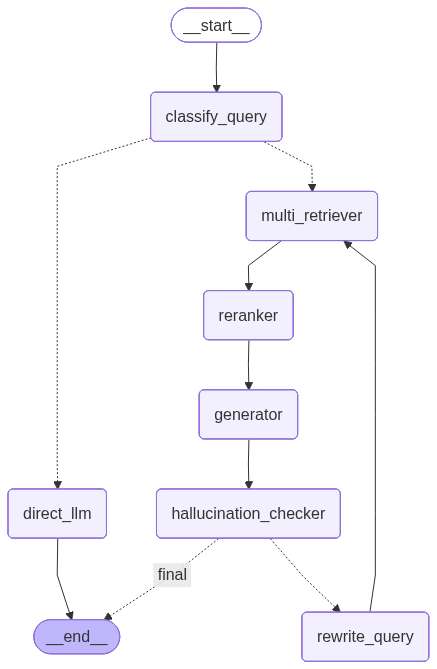

In [50]:
from IPython.display import Image,display
from langgraph.graph import START,END,StateGraph

workflow=StateGraph(GraphState)

#nodes
workflow.add_node("classify_query",classify_query)
workflow.add_node("direct_llm",direct_llm)
workflow.add_node("multi_retriever",multi_retriever)
workflow.add_node("reranker",reranker)
workflow.add_node("generator",generator)
workflow.add_node("hallucination_checker",hallucintaion_checker)
workflow.add_node("rewrite_query",rewrite_query)

#edge
workflow.set_entry_point("classify_query")
workflow.add_conditional_edges("classify_query",route_query,{
    "direct_llm":"direct_llm",
    "multi_retriever":"multi_retriever"
})
workflow.add_edge("direct_llm",END)
workflow.add_edge("multi_retriever","reranker")
workflow.add_edge("reranker","generator")
workflow.add_edge("generator","hallucination_checker")

#hallucination route
workflow.add_conditional_edges("hallucination_checker",
                               check_hallucination,
                               {
                                   "final":END,
                                   "rewrite_query":"rewrite_query"
                               })
workflow.add_edge("rewrite_query","multi_retriever")
graph=workflow.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [53]:
response = graph.invoke({
    "query": "Who works in AI department?",
    "query_type": "",
    "retrieved_docs": [],
    "answer": "",
    "hallucination": "",
    "retry_count": 0
})

print("\nFINAL ANSWER:\n")
print(response["answer"])


FINAL ANSWER:

The AI department is typically staffed by:

- **Chief AI Officer (CAIO)**
- **AI Researchers / Scientists**
- **Machine‑Learning Engineers**
- **Data Analysts / Data Engineers**
- **AI Product Managers**
- **AI Software Developers / AI Agents**
- **AI Ethics & Compliance Specialists**
- **AI Operations / MLOps Engineers**
